# SDOF and MDOF Model Calibration and Compilation

## Introduction

This notebook demonstrates a structured workflow for building and calibrating simplified structural models in OpenSees, covering single-degree-of-freedom (SDOF) and multi-degree-of-freedom (MDOF) systems.

Three worked examples are included:

1. **SDOF Model** — Construct a single-node spring-mass oscillator from a spectral capacity curve (Sd–Sa backbone) using a nonlinear Pinching4 material to capture post-elastic behaviour.

2. **MDOF Stick-and-Mass Model** — Build a multi-storey model in which each floor is a lumped mass connected by a nonlinear zero-length spring. Per-storey drift and shear backbones are specified directly.

3. **Calibrated MDOF Model** — Derive MDOF storey properties automatically from an SDOF capacity curve using the `calibrate_model` function, ensuring the fundamental period and global capacity of the MDOF model match the reference SDOF system.

This workflow supports both simplified seismic performance assessment and regional/portfolio-level evaluations where calibrated MDOF models must be consistent with equivalent SDOF representations.

## References

[1] Priestley, M., Calvi, G. and Kowalski, M. (2007) *Displacement-Based Seismic Design of Structures*. IUSS Press, Pavia.

[2] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. *Earthquake Spectra*. 2020;36(2):806–831. doi:10.1177/8755293019891724

## Initialise Libraries

In [9]:
import numpy as np

from openquake.vmtk.units import units
from openquake.vmtk.modeller import modeller
from openquake.vmtk.calibration import calibrate_model

## Example 1: Compiling an SDOF Model

The SDOF oscillator is built from a spectral capacity curve (`sdof_capacity`) supplied as a 2×n array of Sd [m] and Sa [g] values supporting 2–4 backbone points (bilinear to quadrilinear). A single-element `storey_heights` list sets the effective height, `floor_mass` is set to `[1.0]` for a unit-mass system consistent with a spectral curve, and the `sdof_degradation` flag controls whether the Pinching4 material applies stiffness-strength degradation. The spring drift and force backbones are extracted directly from the capacity array rows before being passed to `modeller`.

In [10]:
# Number of storeys
number_storeys = 1

# Relative storey heights list [in m]
storey_heights = [2.80]

# Relative floor masses list [in tonnes]
floor_mass = [1.0]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [
        [
            0.00060789,
            0.00486316,
            0.02420000,
            0.04353684,
        ],  # spectral displacement [in m]
        [0.10315200, 0.20630401, 0.12378241, 0.12502023],
    ]
)  # spectral acceleration [in g]

# Get inter-storey displacements and shear capacity
storey_drifts = sdof_capacity[0, :]
storey_forces = (
    sdof_capacity[1, :] * units.g * floor_mass[0]
)  # Convert SDOF spectral acceleration to shear force in kN

# Flag to activate default stiffness-strength degradation and pinching4
sdof_degradation = False

### Compile the SDOF Oscillator

The `modeller` class assembles the OpenSees model from the parameters above. Internally, it creates a single zero-length spring element connecting a fixed base to the lumped floor mass. The spring uses a Pinching4 hysteretic material whose backbone is taken directly from `sdof_capacity`.

Once compiled, the model is ready for gravity analysis, modal analysis, static pushover (SPO), cyclic pushover (CPO), or nonlinear response history analysis (NRHA).

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance


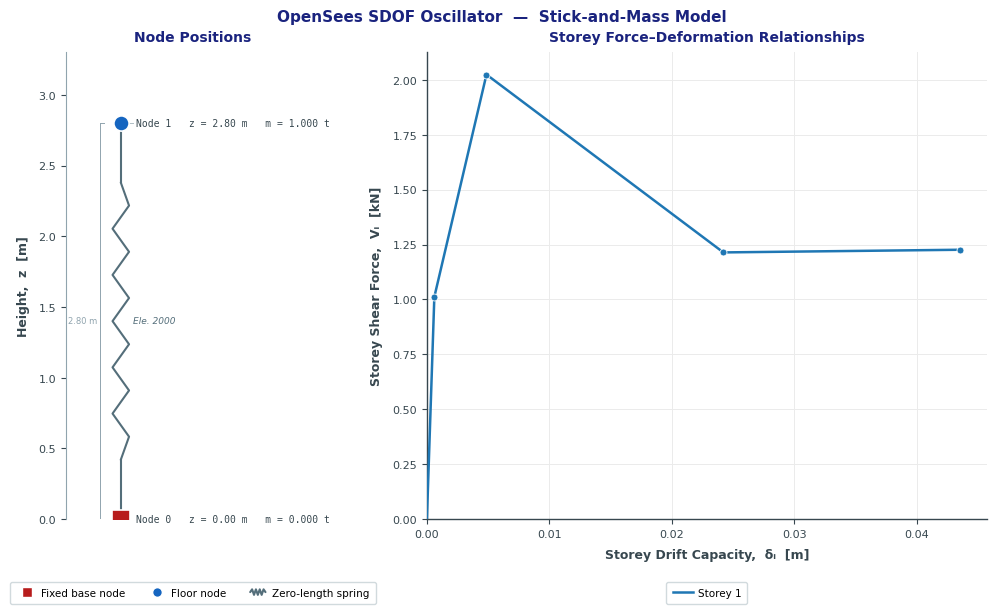

In [11]:
# Initialise the modeller class with model parameters
model = modeller(
    number_storeys,
    storey_heights,
    floor_mass,
    storey_drifts,
    storey_forces,
    sdof_degradation,
)

# Compile the SDOF model in OpenSeesPy
model.compile_model()

# Visualise the model
model.plot_model(pFlag=True, export_path="./out/sdof_model.png")

## Example 2: Compiling an MDOF Stick-and-Mass Model

Each storey requires a row in `storey_drifts` [m] and a matching row in `storey_forces` [kN], each with 2–4 backbone points (bilinear to quadrilinear). The `floor_masses` list assigns a lumped mass to each floor level, and the `mdof_degradation` flag controls whether the Pinching4 material applies stiffness-strength degradation.

In [12]:
# Number of storeys
number_storeys = 3

# Relative floor heights list [in m]
storey_heights = [2.80, 3.00, 3.00]

# Relative floor masses list
floor_masses = [0.33, 0.33, 0.33]  # Lumped masses at each floor [in tonnes]

# MDOF storey drift capacities with a quadrilinear backbone [in m]
storey_drifts = np.array(
    [
        [0.005, 0.010, 0.020, 0.030],  # 1st storey drift capacity
        [0.005, 0.010, 0.020, 0.030],  # 2nd storey drift capacity
        [0.005, 0.010, 0.020, 0.030],
    ]
)  # 3rd storey drift capacity

# MDOF storey shear capacities with a quadrilinear backbone [in kN]
storey_forces = (
    np.array(
        [
            [1.00, 2.00, 1.50, 1.20],  # 1st storey shear capacity
            [1.20, 2.40, 1.80, 1.40],  # 2nd storey shear capacity
            [1.40, 2.80, 2.00, 1.60],
        ]
    )
    * units.kN
)  # 3rd storey shear capacity

# Flag to activate default stiffness-strength degradation and pinching4
mdof_degradation = False

### Compile the MDOF Model

The `modeller` class builds a vertical chain of zero-length spring elements — one per storey — each connecting adjacent floor nodes. Lumped masses are assigned at every floor level. Each spring uses a Pinching4 hysteretic material defined by the per-storey drift and shear backbones specified above.

Once compiled, the model is ready for modal analysis, static pushover (SPO), or nonlinear response history analysis (NRHA).

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


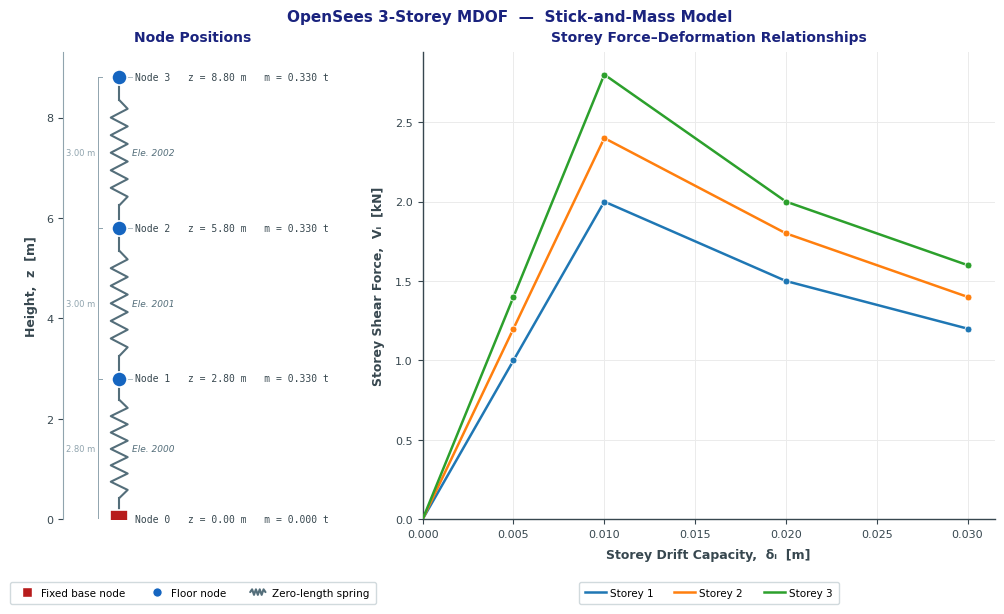

In [13]:
# Initialise the modeller class with model parameters
model = modeller(
    number_storeys,
    storey_heights,
    floor_masses,
    storey_drifts,
    storey_forces,
    mdof_degradation,
)

# Compile the MDOF model in OpenSeesPy
model.compile_model()

# Visualise the model
model.plot_model(pFlag=True, export_path="./out/mdof_model_1.png")

## Example 3: Calibrating an MDOF Model from an SDOF Capacity Curve

`calibrate_model` takes the SDOF spectral capacity curve (n_points × 2, columns Sd [m] and Sa [g]), `storey_heights`, an `is_sos` flag for soft-storey buildings, and an optional `verbose` flag. It returns calibrated `floor_masses`, `storey_drifts`, and `storey_forces` that flow directly into `modeller`; note that `storey_forces` is in g·tonnes and must be multiplied by `units.g` to convert to kN.

In [14]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array(
    [
        [
            0.00060789,
            0.00486316,
            0.02420000,
            0.04353684,
        ],  # spectral displacement [in m]
        [0.10315200, 0.20630401, 0.12378241, 0.12502023],
    ]
).T  # spectral acceleration [in g]

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = False

### Calibrate the MDOF Model

The `calibrate_model` function derives consistent per-storey force-deformation backbones directly from the SDOF spectral capacity curve. The calibration follows three steps:

1. **Period matching** — a mass matrix and relative stiffness profile are constructed from the building geometry, then scaled analytically so that the MDOF fundamental period matches T* = 2π√(Sd₀ / (Sa₀·g)), the period implied by the initial stiffness of the SDOF capacity curve.

2. **Backbone distribution** — the first mode shape and participation factors are used to distribute the SDOF base shear and roof displacement into per-storey shear and drift backbones, following displacement-based design principles [1, 2]. A uniform-ductility assumption is applied so that all storeys share the same displacement backbone shape.

3. **Stiffness consistency** — storey forces are rescaled so that each backbone's implied stiffness is exactly consistent with the analytically scaled stiffness matrix, guaranteeing T* is reproduced in OpenSees without iterative correction.

The function returns `floor_masses`, `storey_drifts`, `storey_forces`, the first mode shape `mdof_phi`, and a `meta` dictionary containing modal properties and the target roof displacement array.

In [15]:
# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

~~~~~~~ ANALYSIS SUCCESSFUL! ~~~~~~~~~


WARNING ZeroLength::setDomain(): Element 2000 has L= 1, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 1, which is greater than the tolerance


### Compile the MDOF Model

The `modeller` class assembles the calibrated OpenSees model using the per-storey properties derived by `calibrate_model`. As in Example 2, it builds a vertical chain of zero-length spring elements — one per storey — each characterised by a Pinching4 hysteretic material. The key difference from Example 2 is that `floor_masses`, `storey_drifts`, and `storey_forces` are not user-specified but flow directly from the calibration output, guaranteeing that the fundamental period and global capacity of this MDOF model are consistent with the reference SDOF system.

Note that `storey_forces` from `calibrate_model` are in g·tonnes and must be multiplied by `g` (9.81 m/s²) to convert to kN before passing to `modeller`.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


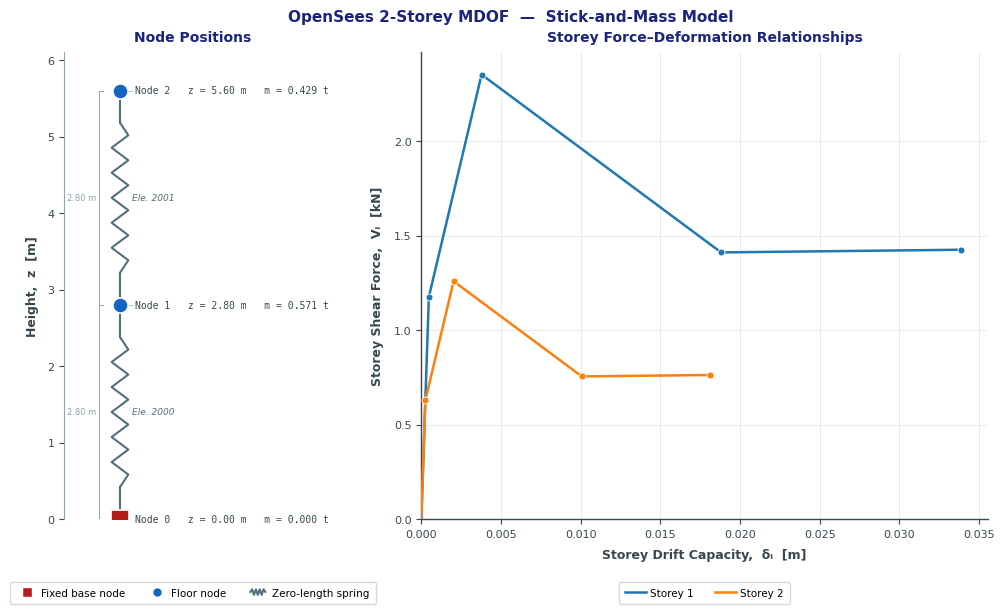

In [16]:
# Initialise the modeller class with calibration results
model = modeller(
    number_storeys,
    storey_heights,
    floor_masses,
    storey_drifts,
    storey_forces * units.g,
    mdof_degradation,
)

# Compile the MDOF model in OpenSeesPy
model.compile_model()

# Visualise the model
model.plot_model(pFlag=True, export_path="./out/mdof_model_2.png")